In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from scipy.interpolate import interp1d
import joblib

In [4]:
ds = xr.open_dataset("windfield_z_100m.nc")
print(ds)

<xarray.Dataset> Size: 1GB
Dimensions:  (t: 901, x: 101, y: 61, z: 11)
Coordinates:
  * t        (t) float64 7kB 0.0 1.0 2.0 3.0 4.0 ... 897.0 898.0 899.0 900.0
  * x        (x) float64 808B 0.0 10.0 20.0 30.0 ... 970.0 980.0 990.0 1e+03
  * y        (y) float64 488B -300.0 -290.0 -280.0 -270.0 ... 280.0 290.0 300.0
  * z        (z) float64 88B 2.5 12.5 22.5 32.5 42.5 ... 72.5 82.5 92.5 102.5
Data variables:
    u        (t, x, y, z) float64 488MB ...
    v        (t, x, y, z) float64 488MB ...
    w        (t, x, y, z) float64 488MB ...
Attributes:
    source:            pdbl_c2_tserie1.h5
    utau:              0.46325
    L:                 1000.0
    velocity_units:    m/s
    coordinate_units:  m


In [5]:

ds.isel(t=slice(0, 900, 10),z=5)['u']

<xarray.DataArray 'u' (t: 90, x: 101, y: 61)> Size: 4MB
[554490 values with dtype=float64]
Coordinates:
  * t        (t) float64 720B 0.0 10.0 20.0 30.0 ... 860.0 870.0 880.0 890.0
  * x        (x) float64 808B 0.0 10.0 20.0 30.0 ... 970.0 980.0 990.0 1e+03
  * y        (y) float64 488B -300.0 -290.0 -280.0 -270.0 ... 280.0 290.0 300.0
    z        float64 8B 52.5

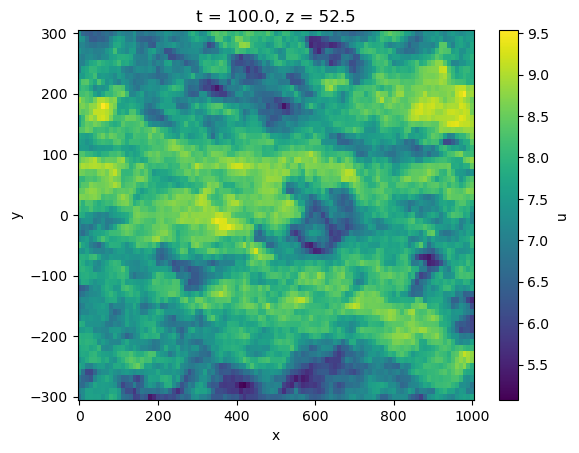

In [6]:

ds.isel(t=100,z=5)['u'].plot(x="x", y="y", cmap="viridis")

In [100]:
def plot_pod_energy(S, threshold=0.8):
    # 1. Calculate Eigenvalues (Energy)
    lambdas = S**2
    
    # 2. Calculate Individual and Cumulative Energy Fraction
    energy_fraction = lambdas / np.sum(lambdas)
    cumulative_energy = np.cumsum(energy_fraction)
    
    # 3. Find the index where we cross the threshold
    n_required = np.argmax(cumulative_energy >= threshold) + 1
    
    # 4. Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Individual Energy (Bar Chart)
    ax1.bar(range(1, len(energy_fraction) + 1), energy_fraction, alpha=0.6, color='g', label='Individual Mode Energy')
    ax1.set_xlabel('Mode Number')
    ax1.set_ylabel('Energy Fraction', color='g')
    ax1.tick_params(axis='y', labelcolor='g')

    # Cumulative Energy (Step/Line Chart)
    ax2 = ax1.twinx()
    ax2.step(range(1, len(cumulative_energy) + 1), cumulative_energy, where='mid', color='b', label='Cumulative Energy')
    ax2.axhline(y=threshold, color='r', linestyle='--', label=f'{int(threshold*100)}% Threshold')
    ax2.axvline(x=n_required, color='r', linestyle=':')
    ax2.set_ylabel('Cumulative Energy Fraction', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    plt.title(f'POD Energy Spectrum (Modes for {int(threshold*100)}% Energy: {n_required})')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()
    
    return n_required


In [101]:
def plot_pod_modes(phi, z_coords, n_modes=10):
    for i in range(n_modes):
        plt.plot(phi(z_coords)[i, :, 0], z_coords, label=f'Mode {i+1}')
    plt.title('POD Modes')
    plt.xlabel('Fluctuation Amplitude')
    plt.ylabel('Height (z)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [103]:
def create_pod_library(ds, threshold=0.9):
    """
    Decomposes LES wind data into a unscaled POD modes.
    
    Returns:
        A dictionary containing callable interpolators for modes and coefficients,
        plus eigenvalues for TKE scaling in the solver.
    """
    # 1. Prepare Dimensions
    n_t, n_x, n_y, n_z = len(ds.t), len(ds.x), len(ds.y), len(ds.z)
    z_coords = ds.z.values
    samples = np.arange(n_t*n_x*n_y) # (t, x, y)

    # 2. Flatten and Subtract the Time-Mean Vertical Profile
    # We subtract the mean(t, x, y) for each height to focus on fluctuations (gusts)
    u_mean = ds.u.mean(dim=['t', 'x', 'y']).values # (z,)
    v_mean = ds.v.mean(dim=['t', 'x', 'y']).values # (z,)
    w_mean = ds.w.mean(dim=['t', 'x', 'y']).values # (z,)

    # Standard Augmented Flattening: stack preserves the spatial correlation
    u_prime = (ds.u - u_mean).stack(samples=('t', 'x', 'y')).values
    v_prime = (ds.v - v_mean).stack(samples=('t', 'x', 'y')).values
    w_prime = (ds.w - w_mean).stack(samples=('t', 'x', 'y')).values
    
    # Combined snapshot matrix X: (3*z, samples)
    X = np.vstack([u_prime, v_prime, w_prime])

    # 3. SVD
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    # Determine number of modes based on energy threshold
    n_modes = plot_pod_energy(S, threshold=threshold)

    # 4. Scale and Reshape Spatial Modes (Phi)
    # Explicitly split components from U: (3*z, n_modes)
    # Rows 0:n_z -> u component, n_z:2*n_z -> v component, 2*n_z:3*n_z -> w component
    U_modes = U[0:n_z, :n_modes]           # (n_z, n_modes)
    V_modes = U[n_z:2*n_z, :n_modes]      # (n_z, n_modes)
    W_modes = U[2*n_z:3*n_z, :n_modes]    # (n_z, n_modes)
    
    # Stack components into modes_array: (n_modes, n_z, 3)
    # This represents the vertical 'shape' of the gusts for each component
    modes_array = np.stack([U_modes.T, V_modes.T, W_modes.T], axis=2)  # (n_modes, n_z, 3)

    # 5. Scale and Reshape Temporal/Spatial Coefficients (a)
    # Multiply Singular Values (S) into Vh to get physical m/s units
    coeffs = Vh[:n_modes, :]  # (n_modes, samples)
    coeffs = coeffs.reshape(n_modes, n_t*n_x*n_y)  # (n_modes, t*x*y)
    
    plt.scatter(coeffs[0], coeffs[1], alpha=0.1)
    plt.xlabel('a_1')
    plt.ylabel('a_2')
    plt.show()

    K = np.cov(coeffs)
    plt.imshow(K, cmap='viridis')
    plt.colorbar(label='Covariance')
    plt.title('Covariance Matrix of POD Coefficients')
    plt.xlabel('Mode Number')
    plt.ylabel('Mode Number')
    plt.show()

    # 6. Build Functional Objects (The "Clean Interface")
    
    # modes_func(z) -> returns (n_modes, 3)
    modes_func = interp1d(z_coords, modes_array, axis=1, bounds_error=False, fill_value="extrapolate")

    plot_pod_modes(modes_func, z_coords, n_modes=n_modes)

    eigenvalues = S**2 / (n_t*n_x*n_y - 1)
    total_energy = np.sum(eigenvalues)
    gamma = eigenvalues[:n_modes] / total_energy

    # 7. Package the Library
    pod_lib = {
        'modes': modes_func,           # Callable z -> modes, direction
        'gamma': gamma,                # TKE fraction for each mode
        'z_coords': z_coords,
    }
    
    joblib.dump(pod_lib, 'pod_library_simple.joblib', compress=3)
    return pod_lib, coeffs, eigenvalues

File not found. Creating new POD library.


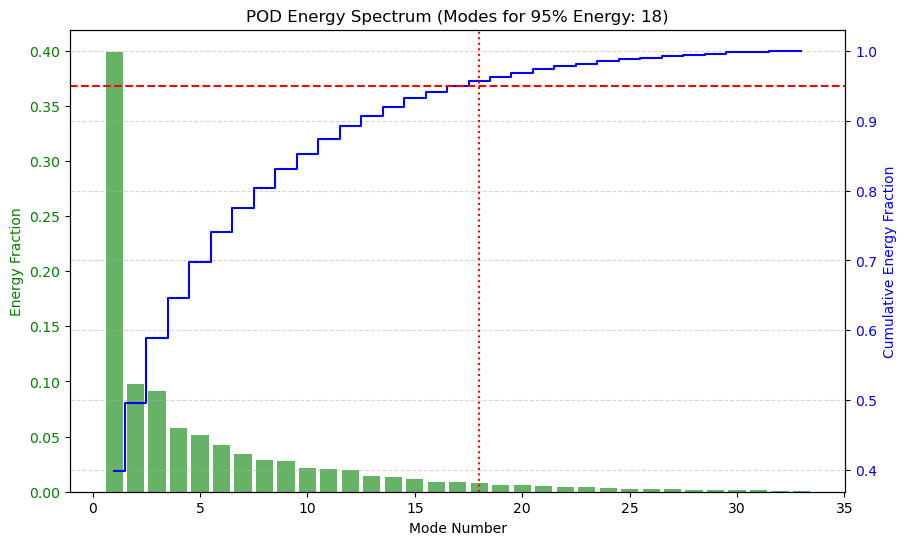

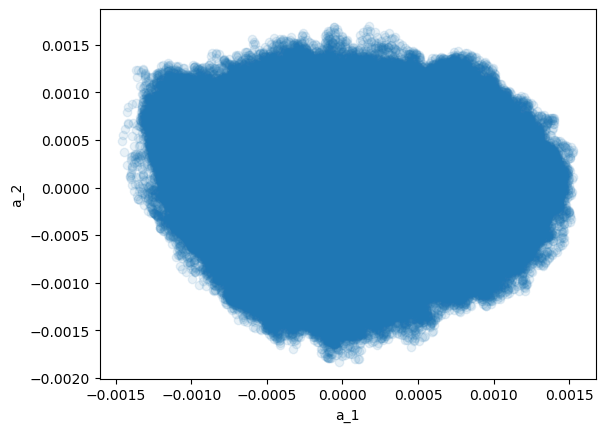

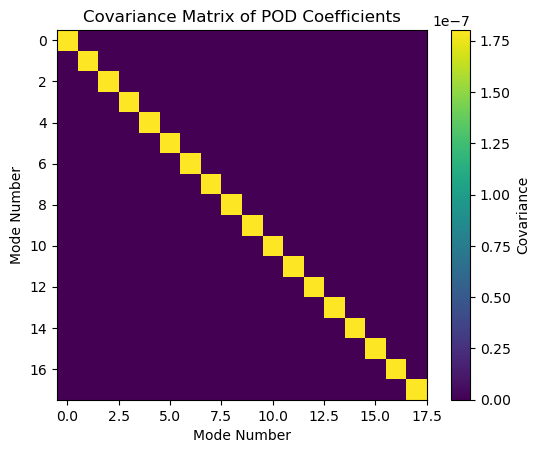

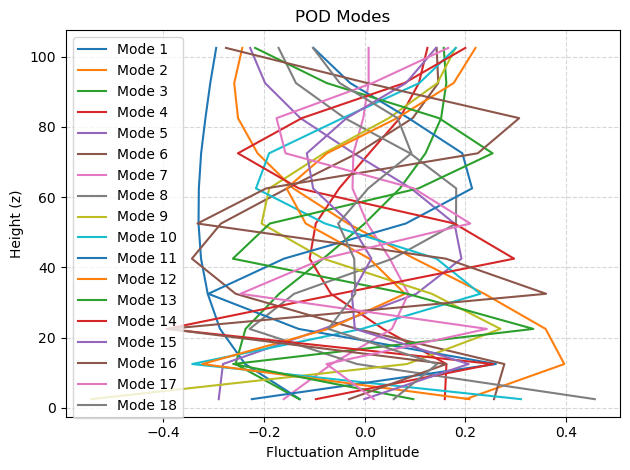

In [104]:
try:
    pod_lib = joblib.load('pod_library2.joblib')
    print("POD library loaded from file.")
except FileNotFoundError:
    print("File not found. Creating new POD library.")
    # pod_lib = create_pod_library(ds.isel(x=slice(50, 50), y=slice(30, 30)), threshold=0.9)
    # pod_lib = create_pod_library(ds.isel(y=slice(30, 30)), threshold=0.9)
    # pod_lib = create_pod_library(ds.isel(t=slice(0, 900, 10)), threshold=0.9) # 40 mb
    pod_lib, coeffs, eigenvalues = create_pod_library(ds, threshold=0.95) # 400 mb (too large)

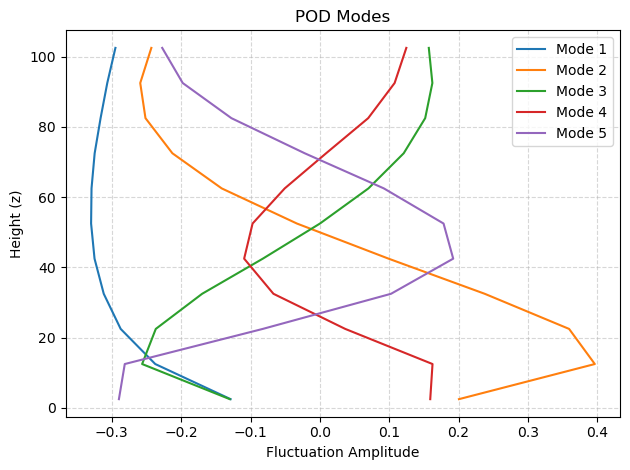

In [105]:
plot_pod_modes(pod_lib['modes'], pod_lib['z_coords'], n_modes=5)

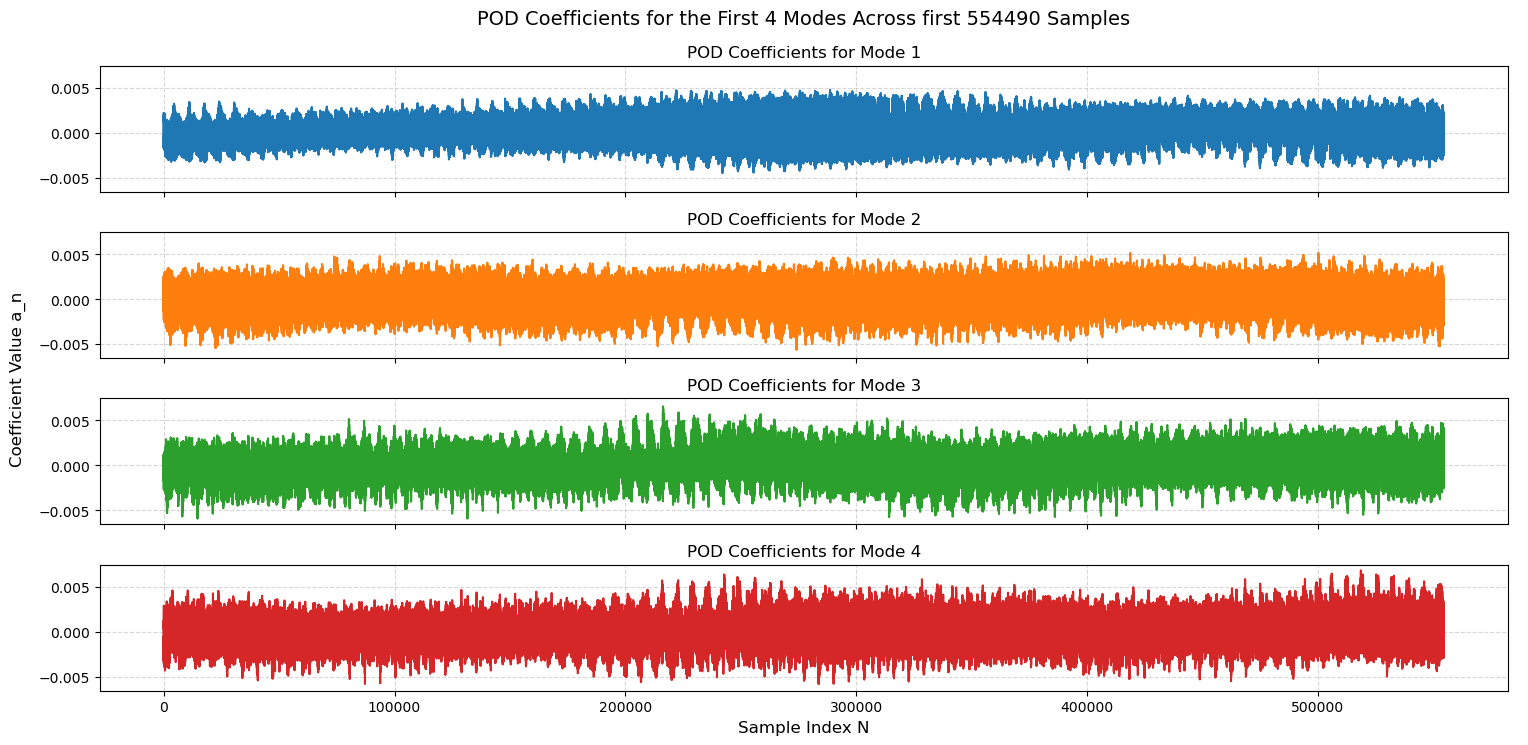

In [11]:
a = pod_lib['coeffs']
samples = pod_lib['samples']

fig, ax = plt.subplots(4,1,figsize=(16, 8), sharex=True, sharey=True)

plot_start = 0 # len(samples) // 2  # Start plotting from the middle of the sample range
plot_n =  len(samples)# 400
for m in range(0,4,1): # Loop over the first 5 modes
    ax[m].plot(range(plot_start, plot_start + plot_n, 1), a[m][plot_start:plot_start + plot_n], color=f'C{m}')
    ax[m].set_title(f'POD Coefficients for Mode {m+1}')
    ax[m].grid(True, which='both', linestyle='--', alpha=0.5)

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across first {plot_n} Samples', fontsize=14, pad=30)
plt.xlabel("Sample Index N", fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

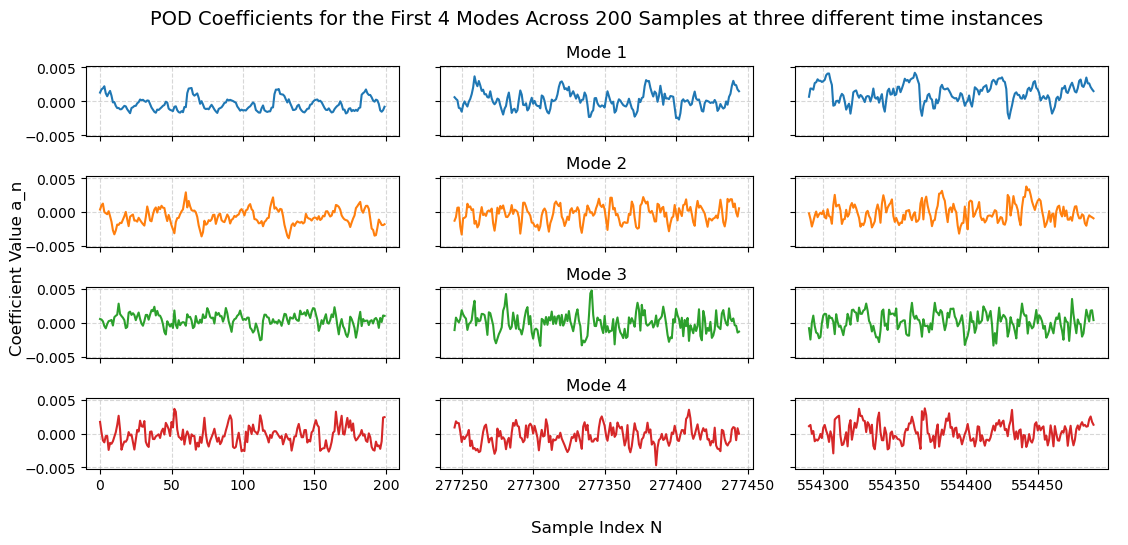

In [12]:
a = pod_lib['coeffs']
samples = pod_lib['samples']

fig, ax = plt.subplots(4,3,figsize=(12, 6), sharey=True, sharex='col')

n = len(samples)
plot_n = 200
shifts = [0, n//2, n-plot_n] # Shift starting points for each mode to visualize different parts of the sample space
for m, shift in enumerate(shifts*4): # Loop over the first 5 modes
    ax[m//3, m%3].plot(range(shift, shift + plot_n, 1), a[m][shift:shift + plot_n], color=f'C{m//3}')
    ax[m//3, 1].set_title(f'Mode {m//3+1}')
    ax[m//3, m%3].grid(True, which='both', linestyle='--', alpha=0.5)

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across {plot_n} Samples at three different time instances', fontsize=14, pad=30)
plt.xlabel("Sample Index N", labelpad=20, fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=20, fontsize=12)
plt.tight_layout()
plt.show()

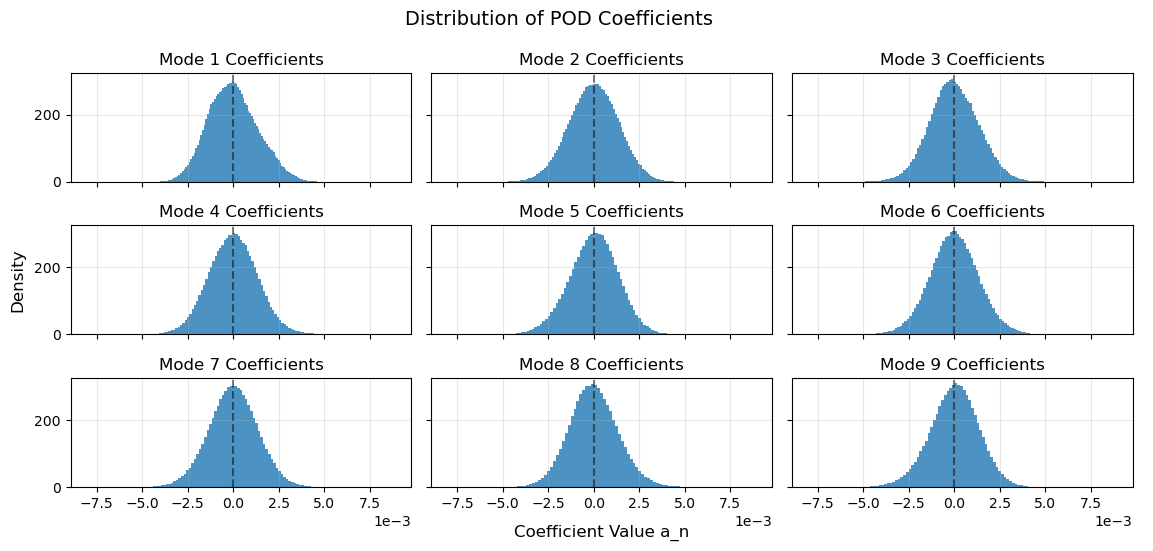

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(12, 6), sharex=True, sharey=True)

for m in range(9):

    data = a[m]
    
    # Plot fordelingen
    axs[m//3, m%3].hist(data, bins=100, density=True, alpha=0.8)
    axs[m//3, m%3].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//3, m%3].set_title(f'Mode {m+1} Coefficients')
    axs[m//3, m%3].grid(alpha=0.3)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
fig.suptitle('Distribution of POD Coefficients', fontsize=14)
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Coefficient Value a_n", labelpad=10, fontsize=12)
plt.ylabel("Density", labelpad=10, fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
## QUICK GUIDE TO USING THE POD LIBRARY FOR RECONSTRUCTION IN THE SOLVER
##
a = pod_lib['coeffs']
phi = pod_lib['modes']
ran_n = np.random.choice(pod_lib['samples'], size=1)[0]
z = 10

# get the first mode's u component at z=10 for the random sample
u_1 = a[0,ran_n] * phi(z)[0,0]

# get the first mode's full component at z=10 for the random sample
U_1 = a[0,ran_n] * phi(z)[0]

# get all modes' u component at z=10 for the random sample
u_N = a[:,ran_n] * phi(z)[:,0]

# get the full fluctuation profile at z=10 for the random sample, all components
U_N = a[:,ran_n] @ phi(z)

# get the full fluctuation profile across all heights for the random sample
U_N_all = a[:,ran_n] @ phi(np.arange(10)).reshape(10,13, 3)

print("Single mode, single component at z=10:", u_1.shape)
print("Single mode, all components at z=10:", U_1.shape)
print("Full fluctuation profile at z=10 for random sample:", u_N.shape)
print("Full fluctuation profile at z=10 for random sample, all components:", U_N.shape)
print("Full fluctuation profile across all heights for random sample:", U_N_all.shape)

Single mode, single component at z=10: ()
Single mode, all components at z=10: (3,)
Full fluctuation profile at z=10 for random sample: (13,)
Full fluctuation profile at z=10 for random sample, all components: (3,)
Full fluctuation profile across all heights for random sample: (10, 3)


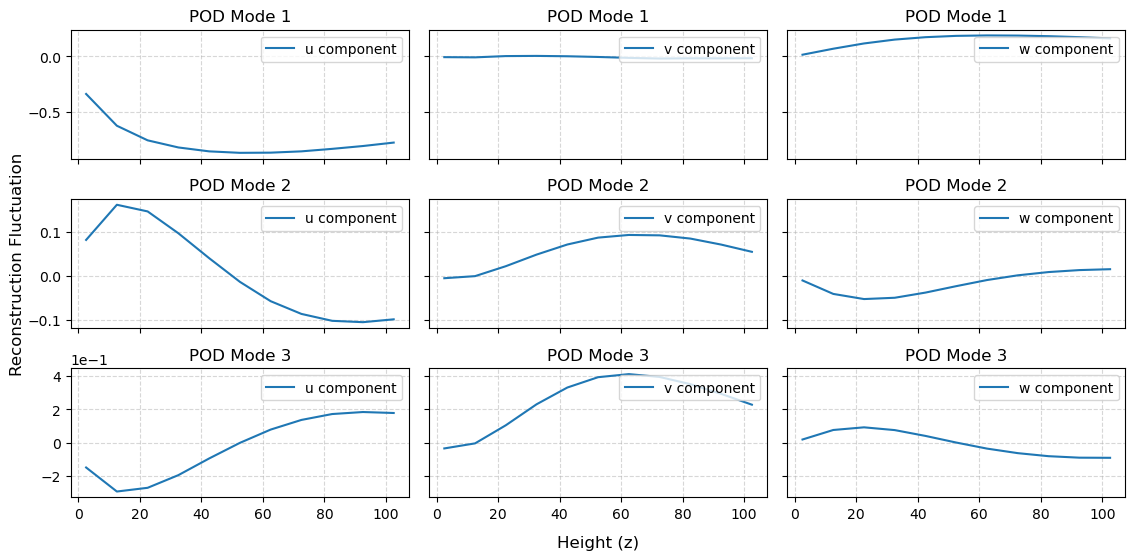

In [46]:
z_coords = pod_lib['z_coords']
a = pod_lib['coeffs']
fig, ax = plt.subplots(3, 3, figsize=(12, 6), sharex=True, sharey='row')
for i, comp in enumerate(['u', 'v', 'w']):
    for m in range(3):
        ax[m, i].plot(z_coords, phi(z_coords)[m, :, i] * a[m, 0], label=f'{comp} component')
        ax[m, i].set_title(f'POD Mode {m+1}')
        ax[m, i].grid(True, which='both', linestyle='--', alpha=0.5)
        ax[m, i].legend(loc='upper right')

        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Height (z)", labelpad=10, fontsize=12)
plt.ylabel("Reconstruction Fluctuation", labelpad=10, fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
n_modes = 2
phi = pod_lib['modes']
a = pod_lib['coeffs']
gamma = pod_lib['gamma']
z = 10
ran_n = 1
a[:n_modes, ran_n] @ phi(z)[:n_modes]

tke_rans = [10,10]

np.sqrt(2*tke_rans[1]*gamma[:n_modes])

array([2.82485127, 1.3966847 ])

In [108]:
def plot_scaled_pod(pod_lib, n_modes, wind: WindField, ax=None):
    tke_rans = wind.ds.tke.values
    z_coords = wind.ds.z.values

    phi = pod_lib['modes']
    gamma = pod_lib['gamma'][:n_modes]

    # 1. Draw standard normal random variables (variance = 1.0) for each mode.
    # This keeps the coefficients pristine until we apply the exact target scaling.
    ran = np.random.normal(loc=0.0, scale=1.0, size=n_modes)

    prime = np.zeros((3, len(tke_rans)))

    for i, z in enumerate(z_coords):
        # 2. Compute the exact physical standard deviation vector for all modes at this height
        # Shape: (n_modes,)
        sigma_target = np.sqrt(2.0 * tke_rans[i] * gamma)
        
        # 3. Scale the random coefficients to their physical target
        # Shape: (n_modes,)
        a_local = ran * sigma_target
        
        # 4. Reconstruct the velocity components smoothly
        if n_modes == 1:
            raw_prime = a_local[0] * phi(z)[0]
        else:
            raw_prime = a_local @ phi(z)[:n_modes] 
            
        prime[:, i] = raw_prime
        
    if ax is None:
        ax = plt.gca()

    u = wind.ds.U.values + prime[0]
    v = wind.ds.V.values + prime[1]
    w = wind.ds.W.values + prime[2]

    ax.plot(u, wind.ds.z.values, label='U with POD Fluctuations for {0} modes'.format(n_modes))
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Height (m)')

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=60, z0=0.03, z_ref=10


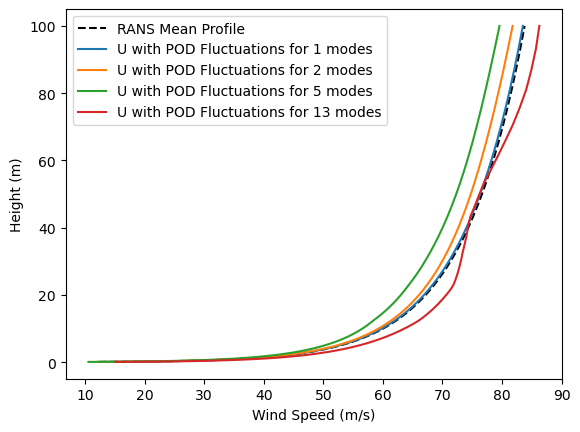

In [109]:
w = WindField(U_ref=60, z_ref=10)
plt.plot(w.ds.U.values, w.ds.z.values, label='RANS Mean Profile', color='k', linestyle='--')
plot_scaled_pod(pod_lib, n_modes=1, wind=w)
plot_scaled_pod(pod_lib, n_modes=2, wind=w)
plot_scaled_pod(pod_lib, n_modes=5, wind=w)
plot_scaled_pod(pod_lib, n_modes=13, wind=w)
plt.legend()

In [87]:
# Calculate the raw, unscaled cross-mode relationships
a = pod_lib['coeffs']
gamma = pod_lib['scale']
k_rans = w.ds.isel(z=99).tke.values
unscaled_cov_matrix = np.cov(a)  # Shape: (M x M)

target_variances = gamma * k_rans  # Length M
scales = np.sqrt(target_variances)   # Standard deviations (Length M)


cov_scaled = unscaled_cov_matrix * np.outer(scales, scales)  # Shape: (M x M)

mean_vector = np.zeros(len(gamma))  # Mean of zero for all modes
rng = np.random.default_rng()

In [90]:
eigenvals = pod_lib['eigenvalues']

mean_vector = np.zeros(len(eigenvals))  # Mean of zero for all modes
a_s = rng.multivariate_normal(mean_vector, np.diag(eigenvals))  # Generate 1000 samples of correlated coefficients
print("Stochastic Coefficients with Multivariate Correlation:\n", a_s)

Stochastic Coefficients with Multivariate Correlation:
 [ 4.28698961  0.60022256 -1.16925131  0.75101381  0.5387545   0.40610644
  0.29459609  0.62879222 -1.48025346 -0.36909207  0.42556848  0.30977503
  0.1599207 ]


Text(0.5, 0, 'Fluctuation Amplitude (m/s)')

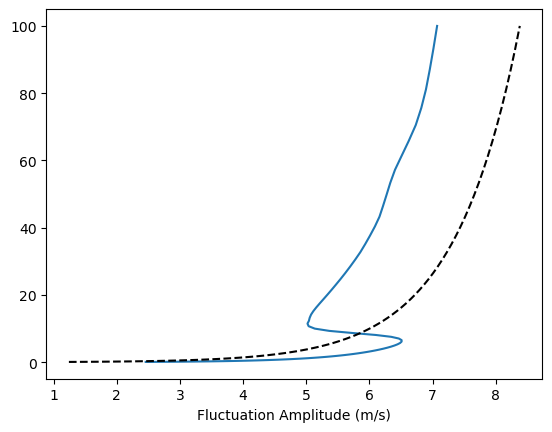

In [91]:
phi = pod_lib['modes']
z = w.ds.z.values  # Example height index
tke = w.ds.tke.values  # RANS TKE profile

U_p = np.array([a_s @ phi(z) for z in z])

tke_pod = 0.5 * (U_p[:, 0]**2 + U_p[:, 1]**2 + U_p[:, 2]**2)  # Calculate TKE from POD fluctuation
gamma = np.sqrt(tke / tke_pod) if any(tke_pod > 0) else 0                          # Scaling factor to match RANS TKE


plt.plot(w.ds.U.values + U_p[:, 0]*gamma, z, label='u component')
plt.plot(w.ds.U.values, z, label='RANS Mean Profile', color='k', linestyle='--')
plt.xlabel('Fluctuation Amplitude (m/s)')

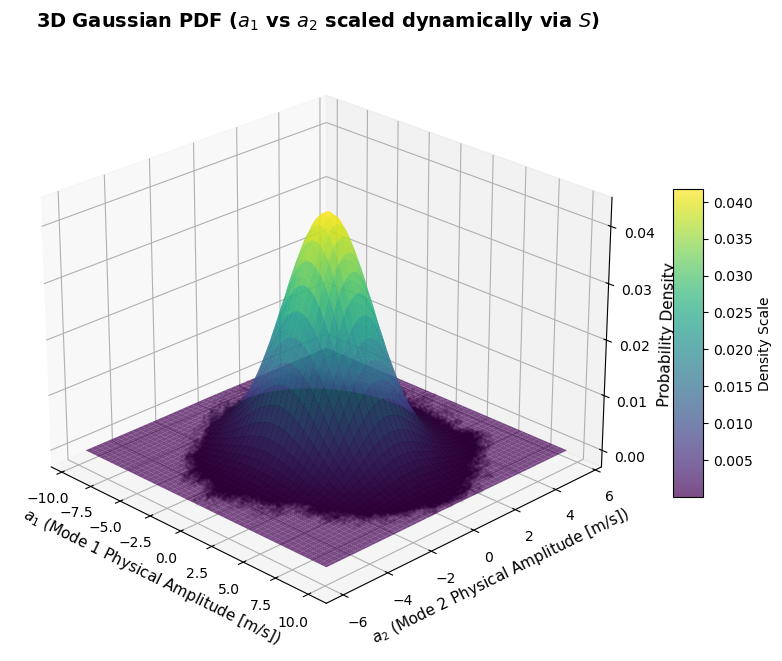

In [35]:
# --- 3D GAUSSIAN DISTRIBUTION PLOT (UNSCALED Vh COEFFS) ---
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal

a = pod_lib['coeffs']
S = pod_lib['sigma']
samples = pod_lib['samples']

# 1. Grab raw, unscaled coefficients from Vh
# coeffs_flat here matches your raw Vh[:n_modes, :]
v1 = a[0]  # First mode coefficients
v2 = a[1]  # Second mode coefficients

# 2. Scale them dynamically just for the statistical calculation
# This keeps your underlying pod_lib clean/unscaled while ensuring
# the 3D plot represents the correct physical amplitudes (m/s)
a1 = v1 * S[0]
a2 = v2 * S[1]

# 3. Calculate the statistical properties from the physically-scaled data
data_matrix = np.vstack([a1, a2])
mean_vector = np.mean(data_matrix, axis=1)
cov_matrix = np.cov(data_matrix)

# 4. Create a 2D grid for the surface plot based on physical limits
x_min, x_max = a1.min(), a1.max()
y_min, y_max = a2.min(), a2.max()

x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Pack grid points for evaluation
pos = np.dstack((x_grid, y_grid))

# 5. Evaluate the mathematical Multivariate Normal PDF over our grid
rv = multivariate_normal(mean=mean_vector, cov=cov_matrix)
z_pdf = rv.pdf(pos)

# 6. Set up the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the elegant 3D Gaussian Surface
surf = ax.plot_surface(
    x_grid, y_grid, z_pdf, 
    cmap=cm.viridis, 
    alpha=0.7, 
    edgecolor='none',
    zorder=2
)

# Project a contour map on the bottom floor
ax.contour(
    x_grid, y_grid, z_pdf, 
    zdir='z', 
    offset=0, 
    cmap=cm.viridis, 
    alpha=0.5
)

# Plot your physically scaled data points as a shadow on the floor (z=0)
ax.scatter(
    a1, a2, np.zeros_like(a1), 
    color='black', 
    alpha=0.05, 
    s=2, 
    label='Scaled LES Data Points',
    zorder=1
)

# Labels and Formatting
ax.set_title('3D Gaussian PDF ($a_1$ vs $a_2$ scaled dynamically via $S$)', fontsize=14, fontweight='bold')
ax.set_xlabel('$a_1$ (Mode 1 Physical Amplitude [m/s])', fontsize=11)
ax.set_ylabel('$a_2$ (Mode 2 Physical Amplitude [m/s])', fontsize=11)
ax.set_zlabel('Probability Density', fontsize=11)

ax.view_init(elev=25, azim=-45)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Density Scale')
plt.show()
# -----------------------------------------------------

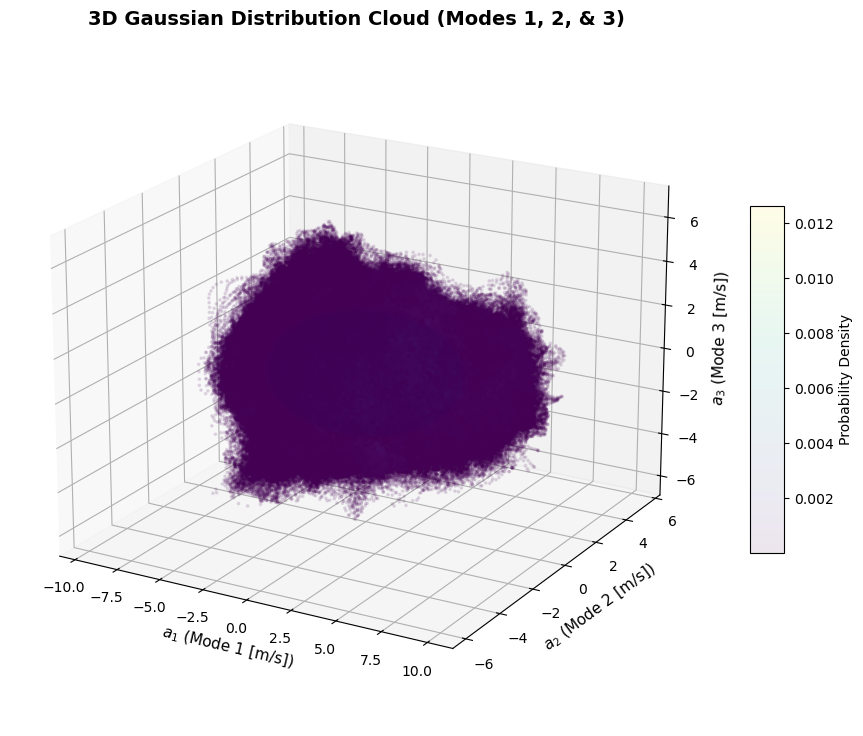

In [36]:
# --- 4D MULTIVARIATE GAUSSIAN PLOT (MODES 1, 2, AND 3) ---
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Grab raw unscaled coefficients and apply singular values
a1 = a[0] * S[0]
a2 = a[1] * S[1]
a3 = a[2] * S[2]

# 2. Calculate 3D statistical properties
data_matrix_3d = np.vstack([a1, a2, a3])
mean_vector_3d = np.mean(data_matrix_3d, axis=1)
cov_matrix_3d = np.cov(data_matrix_3d)

# 3. Evaluate the 3D PDF at every actual data point location
# pos_points shape needs to be (n_samples, 3)
pos_points = data_matrix_3d.T
rv_3d = multivariate_normal(mean=mean_vector_3d, cov=cov_matrix_3d)
density_values = rv_3d.pdf(pos_points)

# 4. Set up the 3D Scatter Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot where color (c) represents the probability density
scat = ax.scatter(
    a1, a2, a3, 
    c=density_values, 
    cmap='viridis', 
    alpha=0.1, 
    s=3
)

# Labels and Formatting
ax.set_title('3D Gaussian Distribution Cloud (Modes 1, 2, & 3)', fontsize=14, fontweight='bold')
ax.set_xlabel('$a_1$ (Mode 1 [m/s])', fontsize=11)
ax.set_ylabel('$a_2$ (Mode 2 [m/s])', fontsize=11)
ax.set_zlabel('$a_3$ (Mode 3 [m/s])', fontsize=11)

# Add colorbar to show density scales
fig.colorbar(scat, ax=ax, shrink=0.5, aspect=10, label='Probability Density')

ax.view_init(elev=20, azim=-60)
plt.show()